# Lista de Exercícios – Regressão Linear com Base de Logística

## Problema: prever tempo de entrega

Neste notebook, vamos trabalhar com uma base simulada de uma empresa de entregas.

A empresa quer prever o **tempo de entrega em minutos** com base em características do pedido e da entrega.

## Objetivo geral

Criar modelos de regressão linear para prever:

> quanto tempo uma entrega deve demorar.

Essa é uma aplicação mais próxima de problemas reais de empresas, e-commerce, logística e sistemas de roteirização.

# Contexto da base

Cada linha representa um pedido entregue.

## Colunas

| Coluna | Descrição |
|---|---|
| id_pedido | Identificador do pedido |
| distancia_km | Distância entre loja/centro de distribuição e cliente |
| peso_kg | Peso total do pedido |
| qtd_itens | Quantidade de itens no pedido |
| valor_pedido | Valor total do pedido |
| trafego | Condição do tráfego: baixo, medio ou alto |
| clima | Condição climática: normal, chuva ou forte_chuva |
| tipo_entrega | normal ou expressa |
| regiao | centro, bairro ou zona_rural |
| tempo_entrega_min | Tempo de entrega em minutos |
| atrasou | Indica se a entrega passou de 120 minutos |

## Variável alvo para regressão

A variável que queremos prever é:

`tempo_entrega_min`

# Importação das bibliotecas

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Criando a base de dados

In [2]:
df = pd.read_csv('base_logistica_entregas.csv')

# Parte A – Exploração inicial da base

## Exercício 1
Mostre as 10 primeiras linhas da base.

## Exercício 2
Mostre as 10 últimas linhas da base.

## Exercício 3
Use `.info()` para verificar os tipos de dados.

## Exercício 4
Use `.describe()` para analisar as variáveis numéricas.

## Exercício 5
Verifique se há valores nulos.

## Exercício 6
Quantas linhas e colunas existem?

## Exercício 7
Qual é a variável alvo do problema de regressão?

## Exercício 8
Quais variáveis parecem ser boas candidatas para prever tempo de entrega?

## Exercício 9
Quais variáveis são categóricas?

## Exercício 10
Por que não podemos usar variáveis categóricas diretamente na regressão linear sem tratamento?

In [4]:
df.head(10)

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
0,1,56.0,16.4,9,2158.92,medio,normal,expressa,bairro,160,sim
1,2,23.6,2.2,9,1431.91,baixo,normal,normal,zona_rural,119,nao
2,3,18.9,19.7,5,464.30,medio,normal,normal,bairro,132,sim
3,4,44.6,29.9,5,1290.63,baixo,chuva,normal,bairro,176,sim
4,5,57.8,23.1,1,1899.66,medio,normal,expressa,bairro,158,sim
5,6,34.4,17.3,2,301.96,baixo,forte_chuva,normal,zona_rural,168,sim
6,7,78.5,3.3,10,2048.23,medio,normal,expressa,bairro,196,sim
7,8,55.1,21.1,1,443.68,baixo,normal,normal,centro,157,sim
8,9,39.0,19.9,8,1349.17,medio,normal,expressa,centro,158,sim
9,10,32.0,1.7,6,982.79,medio,normal,normal,centro,122,sim


In [5]:
df.tail(10)

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
190,191,17.3,2.8,4,1323.99,baixo,chuva,expressa,centro,61,nao
191,192,57.7,10.5,9,1929.33,medio,chuva,normal,bairro,212,sim
192,193,30.9,28.3,1,1558.34,medio,chuva,normal,zona_rural,175,sim
193,194,53.8,14.8,9,1268.27,medio,forte_chuva,normal,centro,235,sim
194,195,3.3,8.3,1,1504.90,medio,normal,normal,zona_rural,73,nao
195,196,51.2,10.9,1,1897.47,medio,chuva,normal,centro,171,sim
196,197,3.5,6.5,11,1356.59,alto,forte_chuva,expressa,centro,149,sim
197,198,59.8,12.8,10,2247.45,medio,normal,expressa,bairro,208,sim
198,199,38.4,6.7,3,2369.26,medio,chuva,normal,centro,165,sim
199,200,10.6,25.4,6,2290.93,medio,normal,normal,centro,133,sim


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_pedido          200 non-null    int64  
 1   distancia_km       200 non-null    float64
 2   peso_kg            200 non-null    float64
 3   qtd_itens          200 non-null    int64  
 4   valor_pedido       200 non-null    float64
 5   trafego            200 non-null    str    
 6   clima              200 non-null    str    
 7   tipo_entrega       200 non-null    str    
 8   regiao             200 non-null    str    
 9   tempo_entrega_min  200 non-null    int64  
 10  atrasou            200 non-null    str    
dtypes: float64(3), int64(3), str(5)
memory usage: 22.7 KB


In [7]:
df.describe()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,40.757500,14.814500,5.950000,1343.555900,158.355000
std,57.879185,21.046217,8.801453,3.081392,718.343381,49.450437
min,1.000000,1.200000,0.300000,1.000000,35.170000,44.000000
25%,50.750000,25.075000,7.300000,3.000000,705.650000,126.000000
50%,100.500000,42.150000,14.050000,6.000000,1352.880000,158.500000
75%,150.250000,57.725000,22.800000,8.250000,1934.770000,189.250000
max,200.000000,79.600000,29.900000,11.000000,2489.780000,286.000000


In [9]:
df.isna().sum()

id_pedido            0
distancia_km         0
peso_kg              0
qtd_itens            0
valor_pedido         0
trafego              0
clima                0
tipo_entrega         0
regiao               0
tempo_entrega_min    0
atrasou              0
dtype: int64

In [13]:
linhas, colunas = df.shape
print(f"A base de dados possui {linhas} linhas e {colunas} colunas.")

A base de dados possui 200 linhas e 11 colunas.


In [15]:
# A variável alvo da regressão será a coluna "tempo_entrega_min".

In [ ]:
# As variáveis distancia_km, trafego, clima, tipo_entrega, região, atrasou são boas candidatas para prever o tempo de entrega.

In [ ]:
# trafego, clima, tipo_entrega, região, atrasou são variáveis categóricas.

In [ ]:
# Não podemos usar variáveis categóricas diretamente na regressão linear, 
# pois precisamos primeramente convertê-las em variáveis dummies (binárias).

# Parte B – Estatística descritiva

## Exercício 11
Calcule a média do tempo de entrega.

## Exercício 12
Calcule a mediana do tempo de entrega.

## Exercício 13
Calcule o desvio padrão do tempo de entrega.

## Exercício 14
Calcule o tempo mínimo e máximo de entrega.

## Exercício 15
Calcule os quartis de `tempo_entrega_min`.

## Exercício 16
Interprete a diferença entre média e mediana.

## Exercício 17
Existe muita variação nos tempos de entrega? Use o desvio padrão para justificar.

## Exercício 18
Existe algum possível outlier no tempo de entrega?

## Exercício 19
Compare o tempo médio de entrega por tipo de entrega.

## Exercício 20
Compare o tempo médio de entrega por condição de tráfego.

In [38]:
def converte_em_minutopos(tempo_str):
    partes = tempo_str.split('.')
    minutos = int(partes[0])
    segundos = float('0.' + partes[1])
    return f"{minutos} minutos e {segundos * 60:.0f} segundos"

tempo_medio_entrega = df['tempo_entrega_min'].mean()
print(f"O tempo médio de entrega é de {converte_em_minutopos(str(tempo_medio_entrega))}.")

O tempo médio de entrega é de 158 minutos e 21 segundos.


In [40]:
mediana_tempo_entrega = df['tempo_entrega_min'].median()
print(f"A mediana do tempo de entrega é de {converte_em_minutopos(str(mediana_tempo_entrega))}.")

A mediana do tempo de entrega é de 158 minutos e 30 segundos.


In [41]:
desvio_padrao_tempo_entrega = df['tempo_entrega_min'].std()
print(f"O desvio padrão do tempo de entrega é de {converte_em_minutopos(str(desvio_padrao_tempo_entrega))}.")

O desvio padrão do tempo de entrega é de 49 minutos e 27 segundos.


In [49]:
tempo_minimo_entrega = df['tempo_entrega_min'].min()
print(f"O tempo mínimo de entra é de {tempo_minimo_entrega} minutos.")
tempo_maximo_entrega = df['tempo_entrega_min'].max()
print(f"O tempo máximo de entrega é de {tempo_maximo_entrega} minutos.")

O tempo mínimo de entra é de 44 minutos.
O tempo máximo de entrega é de 286 minutos.


In [50]:
np.quantile(df['tempo_entrega_min'], [0.25, 0.5, 0.75])

array([126.  , 158.5 , 189.25])

In [ ]:
# Os valores de média e mediana foram próximos, logo a distribuição dos tempo de entrega é simétrica

In [ ]:
# O tempo de entrega tem uma variação de aproximadamente 50 minutos em torno da média.

In [54]:
z_escore_tempo_entrega = (df['tempo_entrega_min'] - tempo_medio_entrega) / desvio_padrao_tempo_entrega
z_escore_tempo_entrega.sort_values(ascending=False)
# Como os valores máximos e mínimos de z-escore estão dentro do intervalo de -3 a 3, não há possíveis outiers no tempo de entrega.

21     2.581271
37     2.500382
24     2.298160
187    2.277937
95     2.257715
         ...   
109   -2.090073
118   -2.090073
28    -2.251851
186   -2.251851
147   -2.312517
Name: tempo_entrega_min, Length: 200, dtype: float64

In [66]:
df.groupby('tipo_entrega')['tempo_entrega_min'].agg(
    ['count', 'mean']
)


,count,mean
tipo_entrega,,
expressa,57,149.894737
normal,143,161.727273


In [69]:
df.groupby('trafego')['tempo_entrega_min'].agg(
    ['count', 'mean']
).sort_values(by='mean', ascending=False)

,count,mean
trafego,,
alto,40,188.075000
medio,93,162.311828
baixo,67,135.119403


# Parte C – Visualização

## Exercício 21
Faça um histograma de `tempo_entrega_min`.

## Exercício 22
Faça um boxplot de `tempo_entrega_min`.

## Exercício 23
Faça um gráfico de dispersão entre `distancia_km` e `tempo_entrega_min`.

## Exercício 24
Faça um gráfico de dispersão entre `peso_kg` e `tempo_entrega_min`.

## Exercício 25
Faça um gráfico de dispersão entre `qtd_itens` e `tempo_entrega_min`.

## Exercício 26
Faça um boxplot de tempo de entrega por `trafego`.

## Exercício 27
Faça um boxplot de tempo de entrega por `clima`.

## Exercício 28
Faça um boxplot de tempo de entrega por `tipo_entrega`.

## Exercício 29
Visualmente, qual variável parece mais relacionada ao tempo de entrega?

## Exercício 30
O gráfico sugere relação linear entre distância e tempo?

Text(0.5, 1.0, 'Distribuição do Tempo de Entrega')

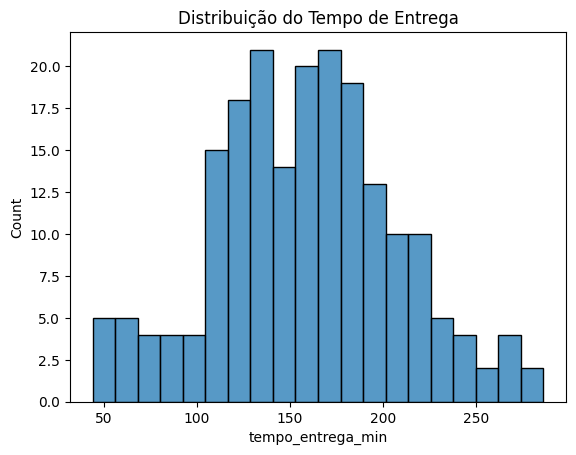

In [76]:
sns.histplot(df['tempo_entrega_min'], bins=20)
plt.title('Distribuição do Tempo de Entrega')

Text(0.5, 1.0, 'Tempo de Entrega - Boxplot')

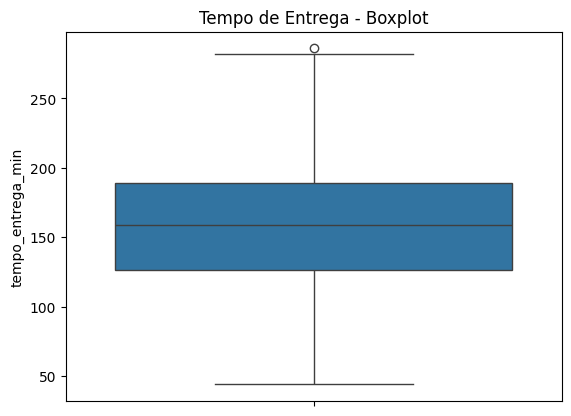

In [82]:
sns.boxplot(y='tempo_entrega_min', data=df)
plt.title('Tempo de Entrega - Boxplot')

Text(0.5, 1.0, 'Tempo de Entrega vs Distância (km)')

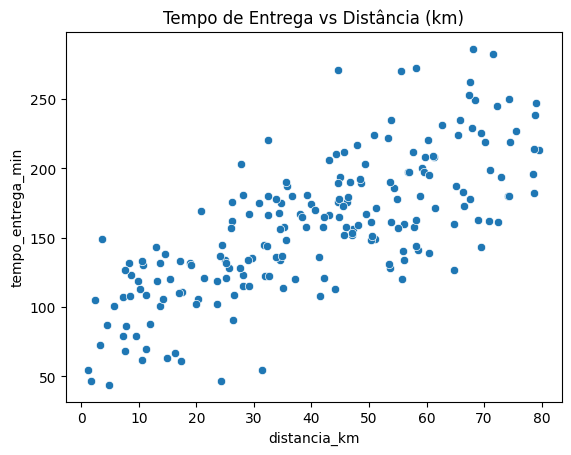

In [84]:
sns.scatterplot(x='distancia_km', y='tempo_entrega_min', data=df)
plt.title('Tempo de Entrega vs Distância (km)')

Text(0.5, 1.0, 'Tempo de Entrega vs Peso (kg)')

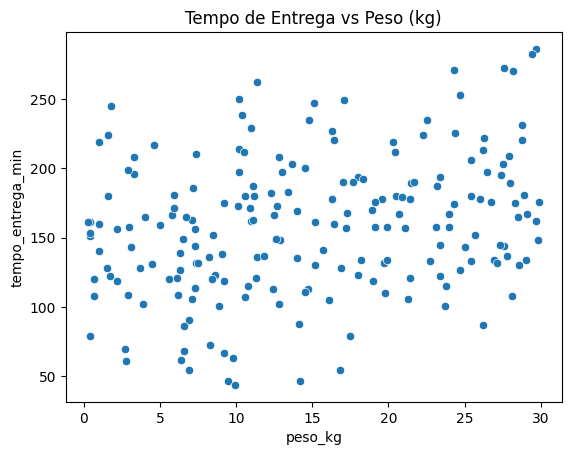

In [85]:
sns.scatterplot(x='peso_kg', y='tempo_entrega_min', data=df)
plt.title('Tempo de Entrega vs Peso (kg)')

Text(0.5, 1.0, 'Tempo de Entrega vs Quantidade de Itens')

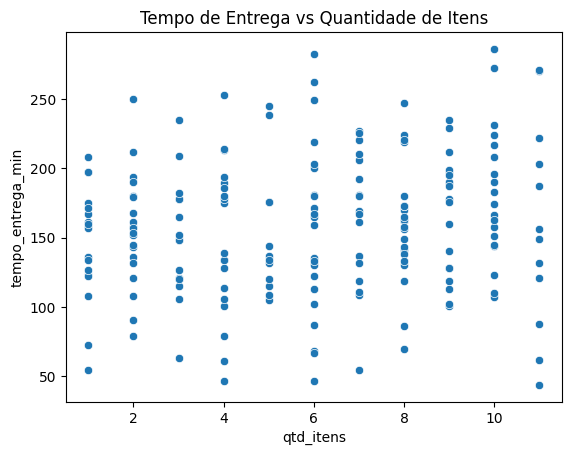

In [86]:
sns.scatterplot(x='qtd_itens', y='tempo_entrega_min', data=df)
plt.title('Tempo de Entrega vs Quantidade de Itens')

Text(0.5, 1.0, 'Tempo de Entrega por Tráfego')

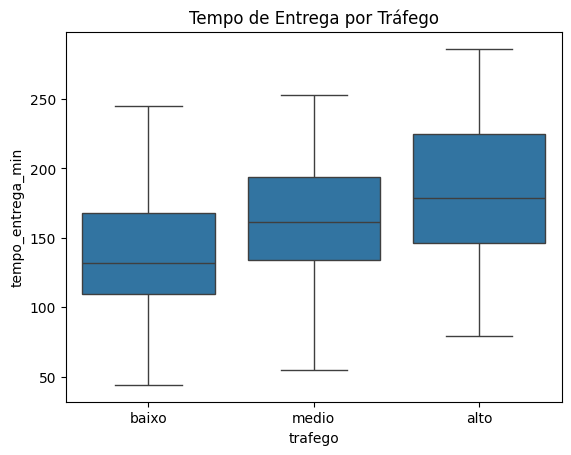

In [94]:
sns.boxplot(x='trafego', y='tempo_entrega_min', data=df.sort_values(by='tempo_entrega_min', ascending=True))
plt.title('Tempo de Entrega por Tráfego')

Text(0.5, 1.0, 'Tempo de Entrega por tipo de Clima')

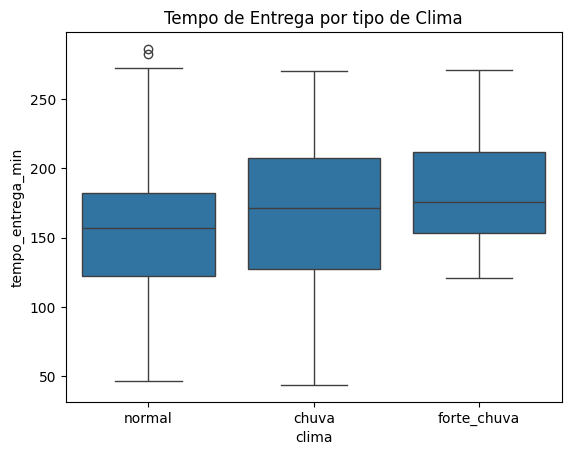

In [96]:
sns.boxplot(x='clima', y='tempo_entrega_min', data=df)
plt.title('Tempo de Entrega por tipo de Clima')

Text(0.5, 1.0, 'Tempo de Entrega por tipo de Entrega')

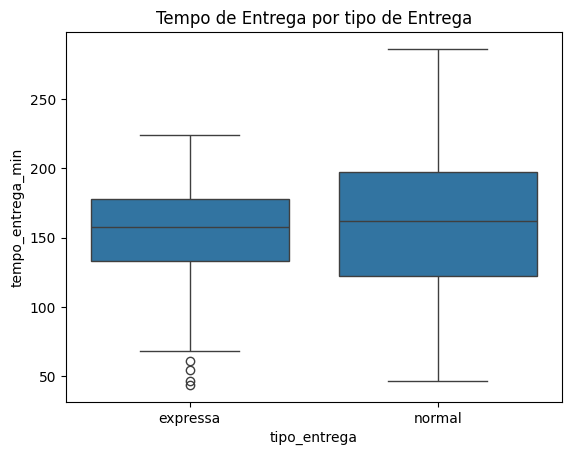

In [98]:
sns.boxplot(x='tipo_entrega', y='tempo_entrega_min', data=df)
plt.title('Tempo de Entrega por tipo de Entrega')

In [ ]:
# Visualmente a variável distancia_km parece ser a mais relacionada ao tempo de entrega.
# Desta forma, sugerindo uma relação linear entre estás variáveis.

# Parte D – Correlação

Para calcular correlação, use apenas variáveis numéricas.

## Exercício 31
Crie um DataFrame apenas com variáveis numéricas.

## Exercício 32
Calcule a matriz de correlação.

## Exercício 33
Faça um heatmap da matriz de correlação.

## Exercício 34
Qual variável numérica tem maior correlação positiva com `tempo_entrega_min`?

## Exercício 35
Qual variável numérica parece ter menor relação com `tempo_entrega_min`?

## Exercício 36
Correlação alta prova causalidade? Explique.

## Exercício 37
Se `valor_pedido` tiver baixa correlação com tempo, isso significa que nunca deve ser usado? Explique.

## Exercício 38
A variável `distancia_km` parece importante? Justifique.

## Exercício 39
A variável `peso_kg` parece importante? Justifique.

## Exercício 40
Quais variáveis você escolheria para um primeiro modelo simples?

In [103]:
df_numerico = df[['distancia_km', 'peso_kg', 'qtd_itens', "valor_pedido", 'tempo_entrega_min']]
df_numerico.corr()

,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min
distancia_km,1.000000,-0.020853,-0.039094,-0.073556,0.743120
peso_kg,-0.020853,1.000000,0.016054,-0.037019,0.280642
qtd_itens,-0.039094,0.016054,1.000000,0.132516,0.156666
valor_pedido,-0.073556,-0.037019,0.132516,1.000000,-0.045193
tempo_entrega_min,0.743120,0.280642,0.156666,-0.045193,1.000000


Text(0.5, 1.0, 'Mapa de Correlação')

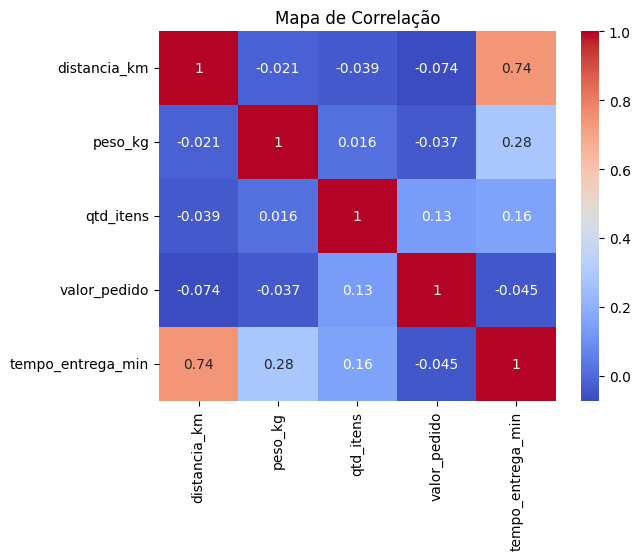

In [106]:
sns.heatmap(df_numerico.corr(), annot=True, cmap='coolwarm')
plt.title('Mapa de Correlação')

In [ ]:
# A variável distancia_km é a que tem a maior correlação com o tempo de entrega mínimo.

In [ ]:
# A Variável valor_pedido tem a menor relação com tempo de entrega mínimo.

In [ ]:
# Não, alta correlação não implica necessariamente em causalidade porque pode existir outros fatores que podem influenciar o tempo de entrega, além de poder ser apenas uma coincidência.


In [ ]:
# A variável valor_pedido pode ter uma baixa correlação com tempo de entrega mínimo, mas isso não significa que ela nunca deveria ser utilizado pois pode ser que em algum momento a correlação dessa variável com o tempo de entrega mínimo aumente, ou seja, a correlação pode variar dependendo do conjunto de dados e do contexto específico.

In [ ]:
# Sim, pois é a variável que apresenta a maior correlação com o tempo de entrega mínimo.

In [ ]:
# Sim, mas nem tanto, pois o resultado da correlação é fraca.

In [ ]:
# Para uma primeiro modelo simples escolheria as variáveis: distancia_km, peso_kg e qtd_itens.

# Parte E – Regressão linear simples

Vamos começar com um modelo simples:

`distancia_km` → `tempo_entrega_min`

## Exercício 41
Crie `X` com a coluna `distancia_km`.

## Exercício 42
Crie `y` com `tempo_entrega_min`.

## Exercício 43
Treine um modelo de regressão linear.

## Exercício 44
Mostre o coeficiente angular.

## Exercício 45
Mostre o intercepto.

## Exercício 46
Interprete o coeficiente angular.

## Exercício 47
Faça previsões para todos os pedidos.

## Exercício 48
Crie uma tabela com tempo real, tempo previsto e erro.

## Exercício 49
Calcule MAE, RMSE e R².

## Exercício 50
Interprete as métricas.

In [ ]:
X = np.array(df['distancia_km']).reshape(-1, 1)
y = df['tempo_entrega_min']

modelo = LinearRegression()
modelo.fit(X, y)

print(f"Coeficiente angular (slope): {modelo.coef_[0]:.4f}")
# Para cada 1 km adicional de distância do local de entrega, o tempo de entrega aumenta em média 1.74 minutos.

Coeficiente angular (slope): 1.7460


In [ ]:
print(f"Intercepto (intercept): {modelo.intercept_:.4f}")
# O intercepto representa o valor de tempo inicial de entrega quando a distância é zero.

Intercepto (intercept): 87.1906


In [123]:
y_previstos = modelo.predict(X)

pd.DataFrame({
        'Tempo de Entrega Real (min)': y,
        'Tempo de Entrega Previsto (min)': y_previstos,
        'Erros': y - y_previstos
    }
)


,Tempo de Entrega Real (min),Tempo de Entrega Previsto (min),Erros
0,160,184.969064,-24.969064
1,119,128.397263,-9.397263
2,132,120.190860,11.809140
3,176,165.064171,10.935829
4,158,188.111942,-30.111942
...,...,...,...
195,171,176.588056,-5.588056
196,149,93.301795,55.698205
197,208,191.604028,16.395972
198,165,154.238703,10.761297


In [128]:
mae = mean_absolute_error(y, y_previstos)
rmse = root_mean_squared_error(y, y_previstos)
r2 = r2_score(y, y_previstos)

print(f"MAE: {mae:.4f} minutos")
print(f"RMSE: {rmse:.4f} minutos")
print(f"R²: {r2:.4f}")

MAE: 26.2844 minutos
RMSE: 33.0073 minutos
R²: 0.5522


In [ ]:
# O erro médio absoluto (MAE) indica que médio, o modelo erra aproximadamente 26.28 minutos
# O erro quadrático médio (RMSE) indica que médio, o modelo erra aproximadamente 33 minutos
# O coeficiente de determinação (R²) indica que o modelo explica 55,22% a variação dos dados em relação a média dos dados.

# Parte F – Visualizando a reta do modelo simples

## Exercício 51
Faça um gráfico de dispersão entre distância e tempo real.

## Exercício 52
Adicione a reta de regressão no gráfico.

## Exercício 53
O modelo parece representar bem os dados?

## Exercício 54
Existem pontos muito distantes da reta?

## Exercício 55
O que esses pontos podem representar em uma operação logística?

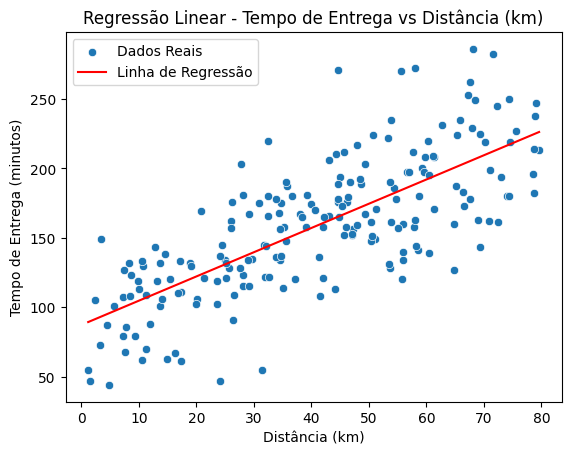

In [135]:
sns.scatterplot(x=X.flatten(), y=y, label='Dados Reais')
sns.lineplot(x=X.flatten(), y=y_previstos, color='red', label='Linha de Regressão')
plt.title('Regressão Linear - Tempo de Entrega vs Distância (km)')
plt.xlabel('Distância (km)')  
plt.ylabel('Tempo de Entrega (minutos)')
plt.legend()

In [ ]:
# Sim, o modelo representa bem os dados.
# Sim, existem pontos muito distantes da reta, mas não tantos.
# Esses pontos distantes podem representar tempos de entrega atípicos.

# Parte G – Fazendo previsões reais

Use o modelo simples com distância.

## Exercício 56
Preveja o tempo de entrega para uma entrega de 5 km.

## Exercício 57
Preveja o tempo de entrega para uma entrega de 20 km.

## Exercício 58
Preveja o tempo de entrega para uma entrega de 60 km.

## Exercício 59
As previsões fazem sentido?

## Exercício 60
Quais informações importantes o modelo simples está ignorando?

In [140]:
modelo.predict([[5], [20], [60]])
# Sim, as previsões fazem sentido, pois o tempo de entrega aumenta conforme a distância.

array([ 95.92085941, 122.11150777, 191.95323674])

In [ ]:
# O modelo simples não incorpora as outras variáveis.

# Parte H – Tratamento de variáveis categóricas

Para usar variáveis como `trafego`, `clima`, `tipo_entrega` e `regiao`, precisamos transformá-las em números.

Uma forma comum é usar `pd.get_dummies()`.

## Exercício 61
Crie uma versão da base com variáveis categóricas transformadas em dummies.

## Exercício 62
Mostre as primeiras linhas da base transformada.

## Exercício 63
Explique o que o `get_dummies()` fez.

## Exercício 64
Por que usamos `drop_first=True`?

## Exercício 65
Quais novas colunas foram criadas?

In [141]:
# Exemplo inicial para a Parte H

df_modelo = pd.get_dummies(
    df,
    columns=["trafego", "clima", "tipo_entrega", "regiao"],
    drop_first=True
)

df_modelo.head()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min,atrasou,trafego_baixo,trafego_medio,clima_forte_chuva,clima_normal,tipo_entrega_normal,regiao_centro,regiao_zona_rural
0,1,56.0,16.4,9,2158.92,160,sim,False,True,False,True,False,False,False
1,2,23.6,2.2,9,1431.91,119,nao,True,False,False,True,True,False,True
2,3,18.9,19.7,5,464.30,132,sim,False,True,False,True,True,False,False
3,4,44.6,29.9,5,1290.63,176,sim,True,False,False,False,True,False,False
4,5,57.8,23.1,1,1899.66,158,sim,False,True,False,True,False,False,False


In [ ]:
# Ele transforma as variáveis categóricas em dummies, ou seja, em variáveis binárias (0 ou 1) indicando a presença ou ausência de cada categoria.

In [ ]:
# O parametro drop_first=True é utilizado para remover a primeira categoria de cada variável categórica, deixando apenas as categorias restantes como variáveis dummies.

In [ ]:
# As colunas que foram criadas foram: trafego_baixo, trafego_medio, clima_forte_chuva, clima_normal, tipo_entrega_normal, regiao_centro, regiao_zona_rural

# Parte I – Regressão linear múltipla

Agora vamos usar várias variáveis ao mesmo tempo.

## Exercício 66
Crie `X` com todas as variáveis explicativas numéricas e dummies.

Não inclua:
- `id_pedido`
- `tempo_entrega_min`
- `atrasou`

## Exercício 67
Crie `y` com `tempo_entrega_min`.

## Exercício 68
Treine um modelo de regressão linear múltipla.

## Exercício 69
Faça previsões.

## Exercício 70
Calcule MAE.

## Exercício 71
Calcule RMSE.

## Exercício 72
Calcule R².

## Exercício 73
Compare com o modelo simples.

## Exercício 74
O modelo múltiplo melhorou?

## Exercício 75
Quais variáveis parecem mais importantes?

<Axes: xlabel='distancia_km'>

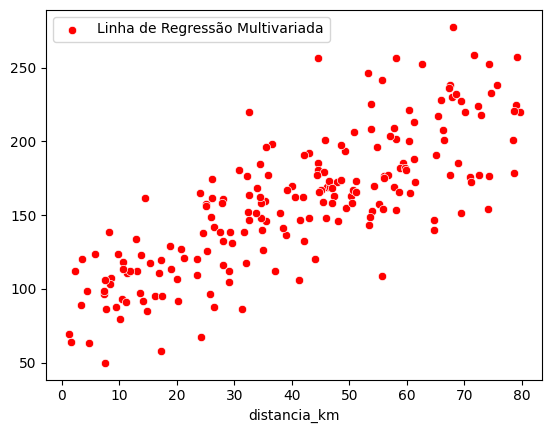

In [ ]:
X = df_modelo.drop(columns=['tempo_entrega_min', 'id_pedido', 'atrasou'])
y = df_modelo['tempo_entrega_min']

modelo_multivariado = LinearRegression()
modelo_multivariado.fit(X, y)


# Parte J – Coeficientes do modelo múltiplo

## Exercício 76
Crie uma tabela com variáveis e coeficientes.

## Exercício 77
Ordene os coeficientes do maior para o menor.

## Exercício 78
Quais coeficientes aumentam o tempo previsto?

## Exercício 79
Quais coeficientes diminuem o tempo previsto?

## Exercício 80
Interprete o coeficiente de `distancia_km`.

## Exercício 81
Interprete o coeficiente de `tipo_entrega_expressa`.

## Exercício 82
Interprete o coeficiente de `trafego_alto`.

## Exercício 83
Interprete o coeficiente de `clima_forte_chuva`.

## Exercício 84
Os sinais dos coeficientes fazem sentido?

## Exercício 85
O que poderia indicar um coeficiente estranho?

In [ ]:
# Espaço para resolver a Parte J

# Parte K – Treino e teste

## Exercício 86
Separe os dados em treino e teste com `test_size=0.3` e `random_state=42`.

## Exercício 87
Treine o modelo nos dados de treino.

## Exercício 88
Faça previsões nos dados de teste.

## Exercício 89
Calcule MAE no teste.

## Exercício 90
Calcule RMSE no teste.

## Exercício 91
Calcule R² no teste.

## Exercício 92
Compare com as métricas do treino.

## Exercício 93
O modelo parece generalizar bem?

## Exercício 94
O que indicaria overfitting?

## Exercício 95
Quais cuidados você teria antes de colocar esse modelo em produção?

In [ ]:
# Espaço para resolver a Parte K

# Parte L – Desafio final: relatório para a empresa

A empresa quer saber se é possível prever o tempo de entrega antes do pedido sair para rota.

## Exercício 96
Treine o melhor modelo que conseguir.

## Exercício 97
Crie uma tabela com:
- tempo real
- tempo previsto
- erro
- erro absoluto

## Exercício 98
Mostre os 10 pedidos com maior erro absoluto.

## Exercício 99
Analise possíveis motivos para os maiores erros.

## Exercício 100
Escreva uma conclusão para a empresa respondendo:

1. O modelo é útil?
2. Qual o erro médio em minutos?
3. Quais variáveis mais influenciam o tempo?
4. O modelo deve ser usado sozinho para tomar decisões?
5. Que melhorias poderiam ser feitas com mais dados?

In [ ]:
# Espaço para resolver a Parte L

# Função auxiliar para avaliação de modelos

Use depois de tentar resolver manualmente.

In [ ]:
def avaliar_regressao(nome, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)

    return {
        "modelo": nome,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

# Fechamento

Com esta lista, você praticou um fluxo mais próximo de um problema real:

- exploração de dados;
- visualização;
- correlação;
- transformação de variáveis categóricas;
- regressão linear simples;
- regressão linear múltipla;
- treino e teste;
- avaliação de modelo;
- interpretação para tomada de decisão.